In [22]:
# setup: imports

import scanpy as sc
import anndata as ad

from anndata import AnnData
from pathlib import Path

from scripts.utils import setup_validate_paths
from scripts.paths import FIGURES, OUTPUT

# setup: path constants

DATA_NB = OUTPUT / "cluster-age-integrated"
FIGURES_NB = FIGURES / "visualize-age-integrated"
OUTDIR_NB = OUTPUT / "visualize-age-integrated"

JOINT = DATA_NB / "poscablo_pne/poscablo_pne.h5ad"
HSC = DATA_NB / "poscablo_pne_hsc/poscablo_pne_hsc.h5ad"
HSPC = DATA_NB / "poscablo_pne_hspc/poscablo_pne_hspc.h5ad"

# setup: verify paths

setup_validate_paths(
    required_paths=[JOINT, HSC, HSPC], output_dirs=[FIGURES_NB, OUTDIR_NB]
)

# can break rendering saved objects in anndata < 0.11
ad.settings.allow_write_nullable_strings = True

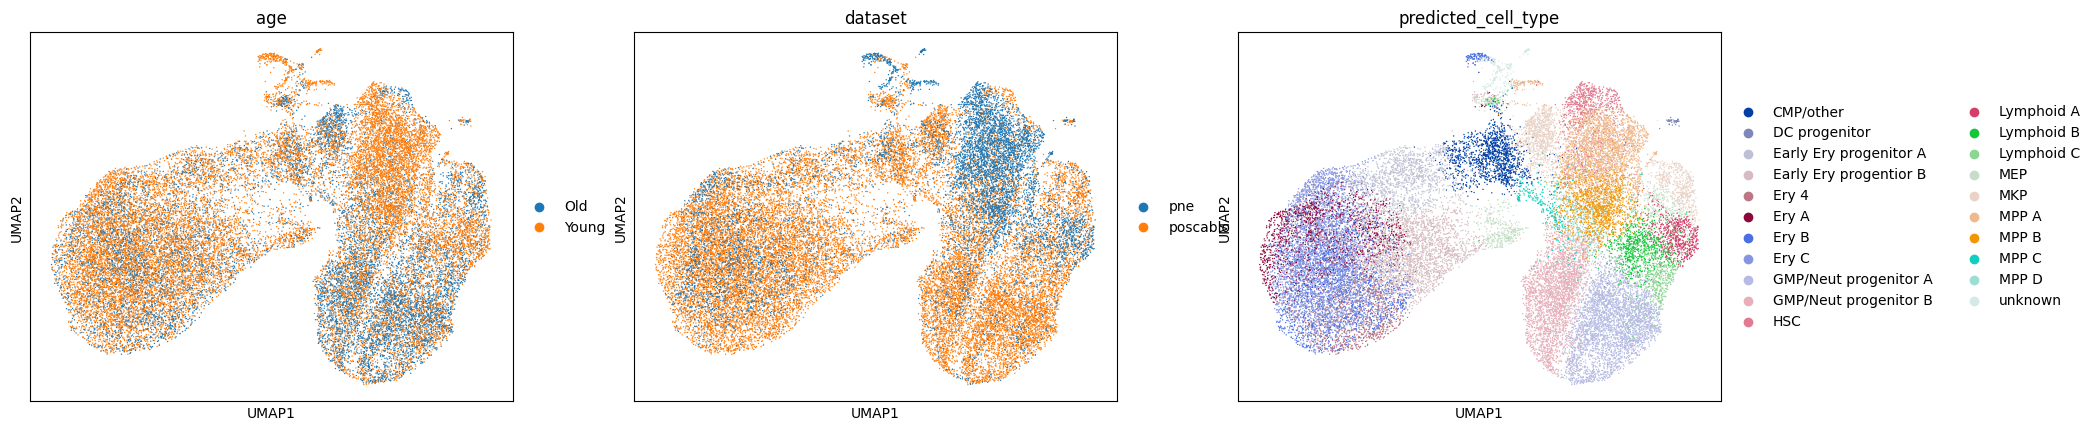

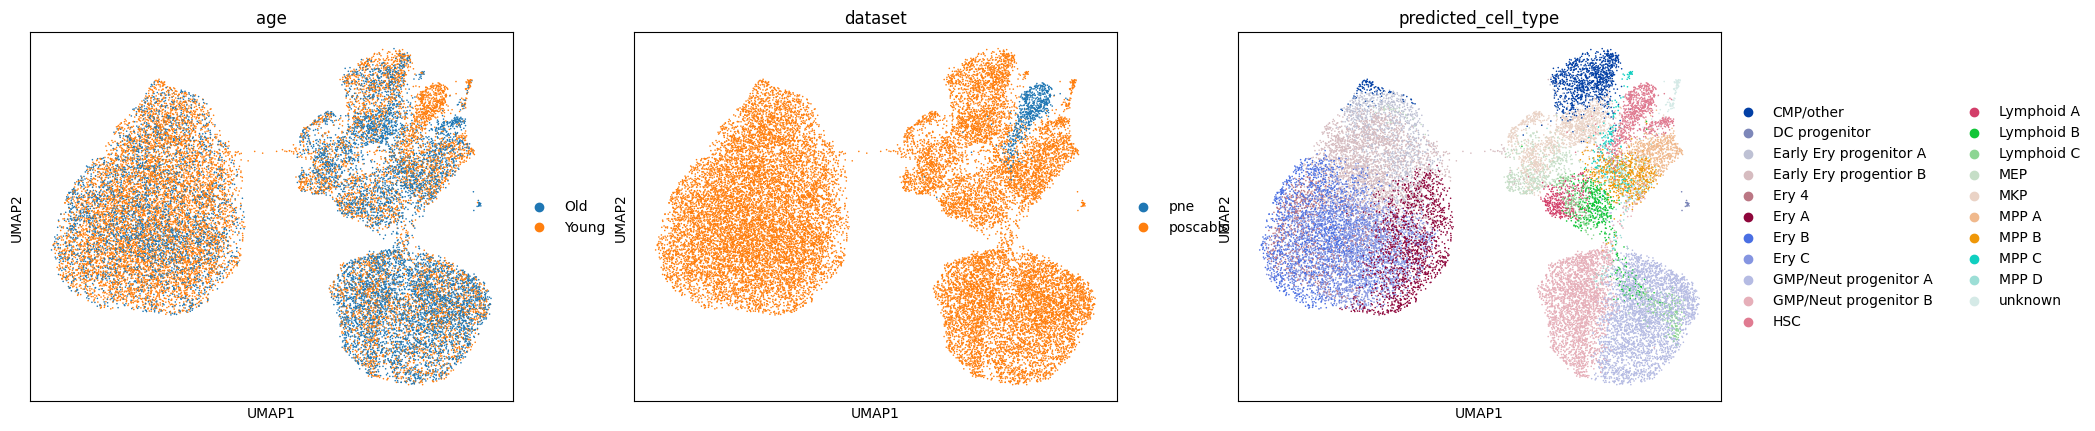

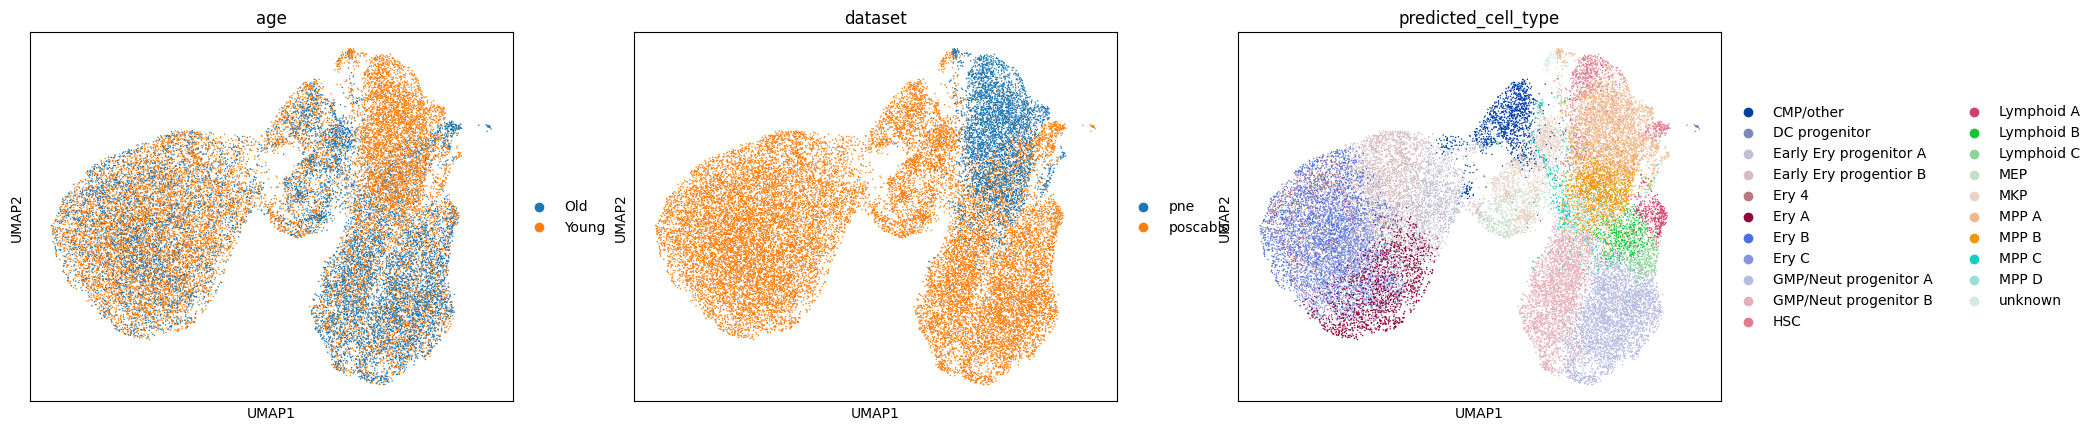

In [ ]:
joint, hsc, hspc = (sc.read_h5ad(path) for path in (JOINT, HSC, HSPC))

for adata in joint, hsc, hspc:
    sc.pl.umap(adata, color=['age', 'dataset', 'predicted_cell_type'])

# top:    joint (poscablo + pne ctrl all)
# mid:    joint (poscablo + pne ctrl hsc)
# bottom: joint (poscablo + pne ctrl hspc)

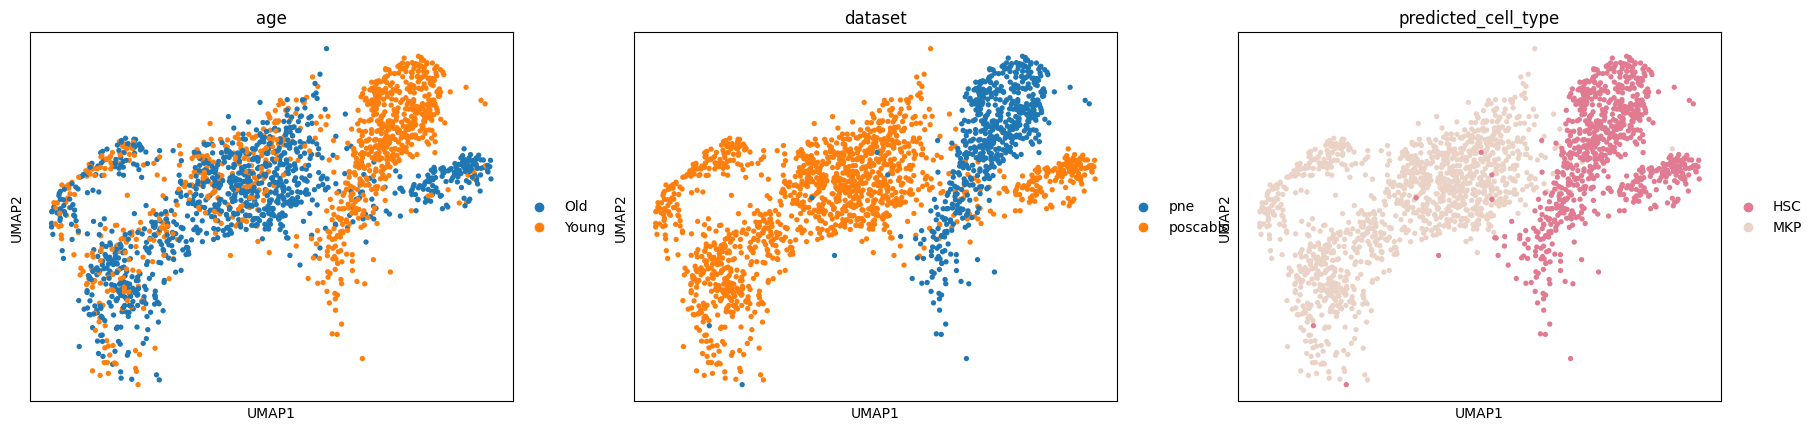

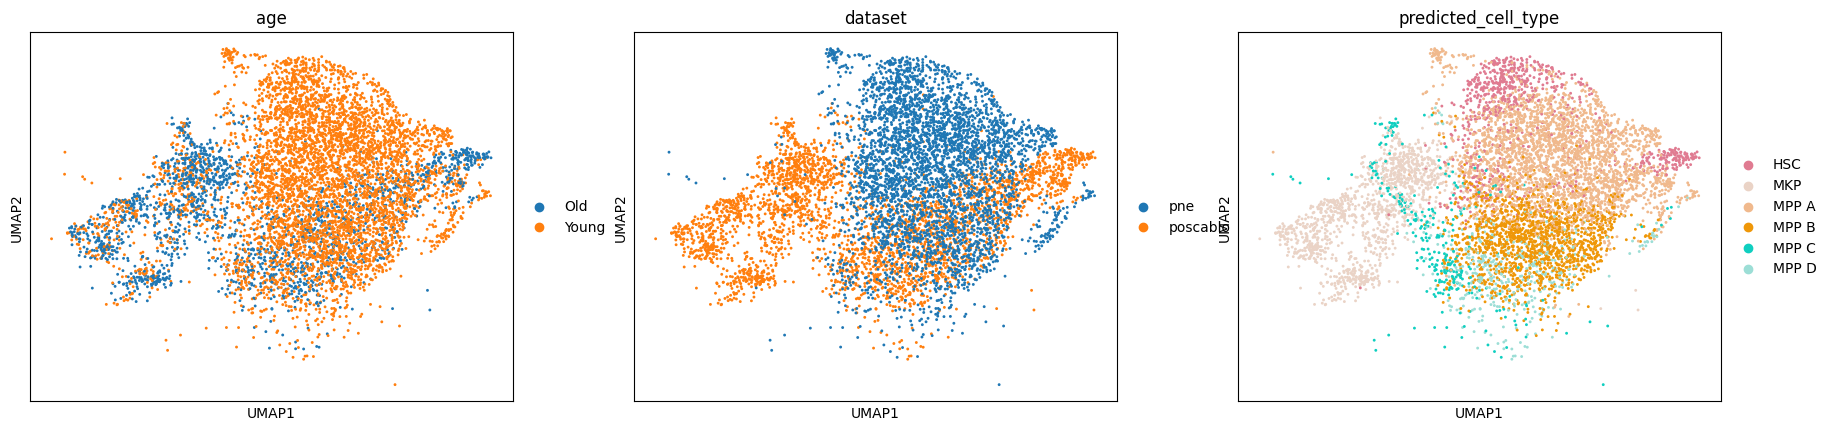

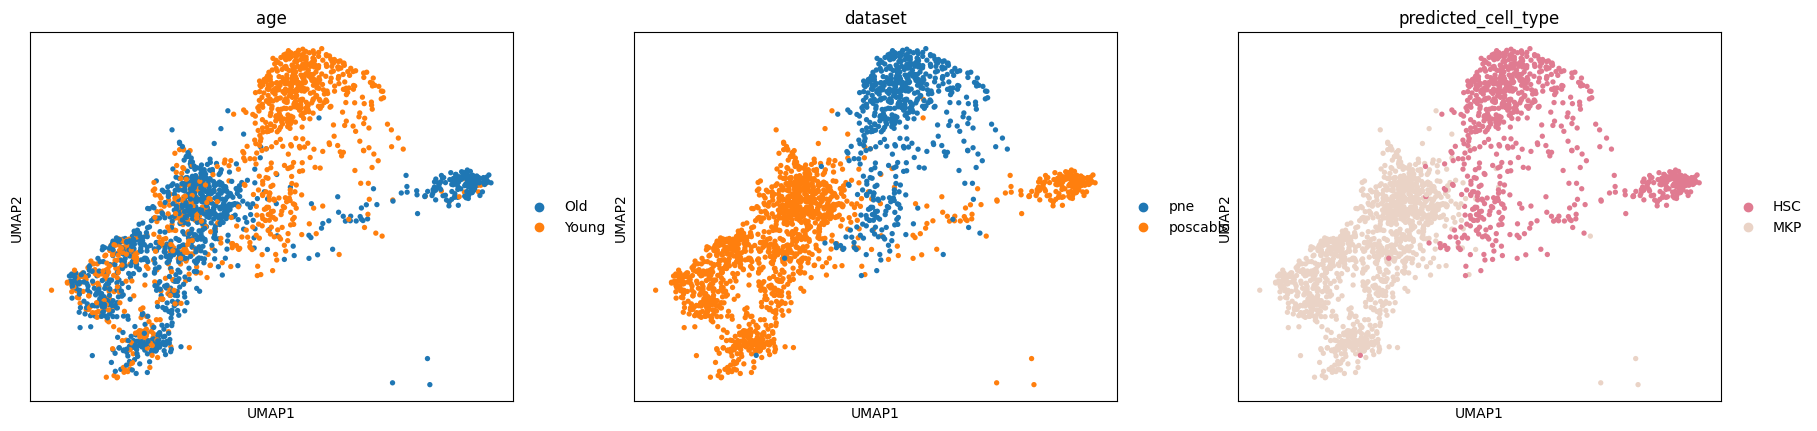

In [ ]:
hsc_cells = ['HSC', 'MKP']
hspc_cells = hsc_cells + ['MPP A', 'MPP B', 'MPP C', 'MPP D']

for adata, cells in (hsc, hsc_cells), (hspc, hspc_cells):
    full_space_view = adata[adata.obs['predicted_cell_type'].isin(cells)]
    hsc_view = adata[adata.obs['predicted_cell_type'].isin(hsc_cells)]

    sc.pl.umap(full_space_view, color=['age', 'dataset', 'predicted_cell_type'])
    if len(hsc_view) != len(full_space_view):
        sc.pl.umap(hsc_view, color=['age', 'dataset', 'predicted_cell_type'])

# top:    poscablo + ctrl pne (HSC): plot HSC,MKP
# mid:    poscablo + ctrl pne (HSC/MPP): plot HSC,MPP,MKP
# bottom: poscablo + ctrl pne (HSC/MPP): plot HSC,MKP